# Problema 1 - Regressão: Predição da Deposição Seca de Cloreto
A deposição de cloreto (Cl^-) é um dos principais fatores de corrosão atmosférica em ambientes marinhos e costeiros. Íons de cloreto presentes no ar reagem com a camada superficial de eletrólitos nos metais como o aço carbono, alumínio, cobre e zinco, e acelera o processo de oxirredução, o que altera a composição do metal.

A norma ISO 9223 classifica ambientes corrosivos em categorias (C1 a CX) que levam em conta, entre outras variáveis, a taxa de deposição de cloreto. Quanto maior o valor de cloreto depositado, mais agressivo é o ambiente.

Neste notebook, o objetivo é prever numericamente a taxa de deposição seca de cloreto a partir das variáveis ambientais e geográficas, o que caracteriza uma tarefa de **regressão**.

### Conjunto de Dados
O dataset "dataset_cl.xlsx" agrupa medições de deposição de cloreto coletadas em estações de medições em todo o mundo, provenientes de vários projetos de pesquisa. As variáveis de entrada utilizadas são:

- **distance_to_coast**: Distância à linha de costa (em km)
- **elevation**: Altitude (em metros) 
- **merra2_sssmass**: Massa de aerossol marinho na atmosfera (dados de reanálise atmosférica do MERRA-2) 
- **era5_wind_speed**: Velocidade média do vento (dados de reanálise atmosférica do ERA5) 
- **era5_time_of_wind**: Tempo de exposição ao vento (dados de reanálise atmosférica do ERA5) 
- **roughness_mean**: Rugosidade média do terreno (considerando a localização da estação até a costa marinha mais próxima) 

A variável-alvo é a **concentração de cl** (em mg/m²/ano).

### Metodologia de Split Treino/Teste
O split foi feito **por projeto**, separando dados de projetos de pesquisa diferentes para treino e teste.
##### Validação Cruzada Interna #####
Dentro do conjunto de treino, é aplicado Random Subsampling Estratificado (Monte Carlo Cross Validation com 100 splits). A estratificação é feita pela coluna salinity_class (faixas de salinidade da ISO 9223 (S0 a S4)), para que cada split mantenha a proporção de cada classe no subconjunto de treino e validação interna.

### Modelos Comparados
- **MLP (nossa biblioteca)**: Rede neural implementada do zero 
- **MLPRegressor (sklearn)**: Rede neural da biblioteca sklearn 
- **Random Forest**: Ensemble de árvores de decisão 
- **SVR**: Support Vector Regressor 

In [1]:
import sys
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('../')
import NNRaw.neural_network as NN

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Carregamento do dataset

In [2]:
df = pd.read_excel('../datasets/dataset_cl.xlsx')
print(f'Shape: {df.shape}')
df.head()

Shape: (430, 10)


,project_name,station_id,start_date,distance_to_coast,elevation,merra2_sssmass,era5_wind_speed,era5_time_of_wind,roughness_mean,cl
0,international_isocorrag_2010,13,1984-10-04 00:00:00,0.16,7.000000,18.34750,4.910216,1.000000,0.0000,30.0
1,international_isocorrag_2010,18,1986-09-08 00:00:00,373.00,427.000000,7.20856,2.725710,0.166667,0.2694,3.8
2,international_isocorrag_2010,19,1986-09-30 00:00:00,426.00,266.087200,12.00420,3.064244,0.416667,0.2172,4.8
3,international_isocorrag_2010,20,1986-09-26 00:00:00,378.16,240.876736,13.14570,2.829206,0.250000,0.2890,3.8
4,international_isocorrag_2010,21,1988-05-26 00:00:00,240.00,116.296867,19.06440,3.476512,0.750000,0.2456,2.5


In [3]:
print(df['cl'].describe())

count    430.000000
mean      53.365294
std      104.606669
min        0.300000
25%        7.660000
50%       18.760000
75%       39.002500
max      760.000000
Name: cl, dtype: float64


In [4]:
X_cols = [
    'distance_to_coast',
    'elevation',
    'merra2_sssmass',
    'era5_wind_speed',
    'era5_time_of_wind',
    'roughness_mean'
]
y_col = 'cl'


## 3. Pré-processamento

A estratificação é usada para garantir que o cross-validation mantenha proporção das faixas de salinidade em cada split. O split treino/teste é feito por projeto de pesquisa.

In [5]:
# Classifica cl em faixas de salinidade para estratificação
def stratify_cl(x):
    if x <= 3:
        return 's0'
    elif x <= 60:
        return 's1'
    elif x <= 300:
        return 's2'
    elif x <= 1500:
        return 's3'
    else:
        return 's4'

df['salinity_class'] = df[y_col].apply(stratify_cl)
print('Distribuição das classes de salinidade:')
print(df['salinity_class'].value_counts().sort_index())

Distribuição das classes de salinidade:
salinity_class
s0     47
s1    305
s2     63
s3     15
Name: count, dtype: int64


In [6]:
train_projects = [
    'international_micat_1998',
    'international_isocorrag_2010',
    'chile_vera_2012',
    'spain_canary_isles_2019',
    'international_cole_2003',
    'brazil_nutec_2008',
    'brazil_sica_2006',
    'brazil_portella_2011',
    'brazil_vitali_2013',
    'brazil_brambilla_2011',
    'brazil_pontes_2011'
]
test_projects = [
    'brazil_portella_2012',
    'brazil_vitali_2013',
    'brazil_brambilla_2011',
    'brazil_pontes_2011'
]

df_train = df[df['project_name'].isin(train_projects)].copy()
df_test  = df[df['project_name'].isin(test_projects)].copy()

print(f'Treino: {len(df_train)} amostras e Teste: {len(df_test)} amostras')

Treino: 423 amostras e Teste: 30 amostras


In [7]:
# Normalização com MinMaxScaler (necessário para a MLP e SVR)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_raw = df_train[X_cols].to_numpy()
y_train_raw = df_train[y_col].to_numpy().reshape(-1, 1)
X_test_raw  = df_test[X_cols].to_numpy()
y_test_raw  = df_test[y_col].to_numpy()

X_train_sc = scaler_X.fit_transform(X_train_raw)
y_train_sc = scaler_y.fit_transform(y_train_raw)
X_test_sc  = scaler_X.transform(X_test_raw)

stratify_train = df_train['salinity_class']

print('Pré-processamento concluído')
print(f'X_train: {X_train_sc.shape} e X_test: {X_test_sc.shape}')

Pré-processamento concluído
X_train: (423, 6) e X_test: (30, 6)


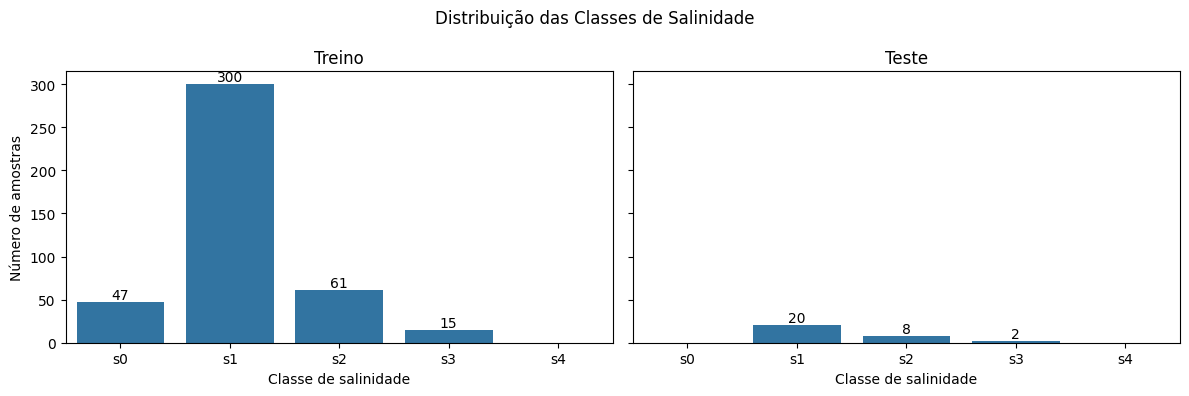

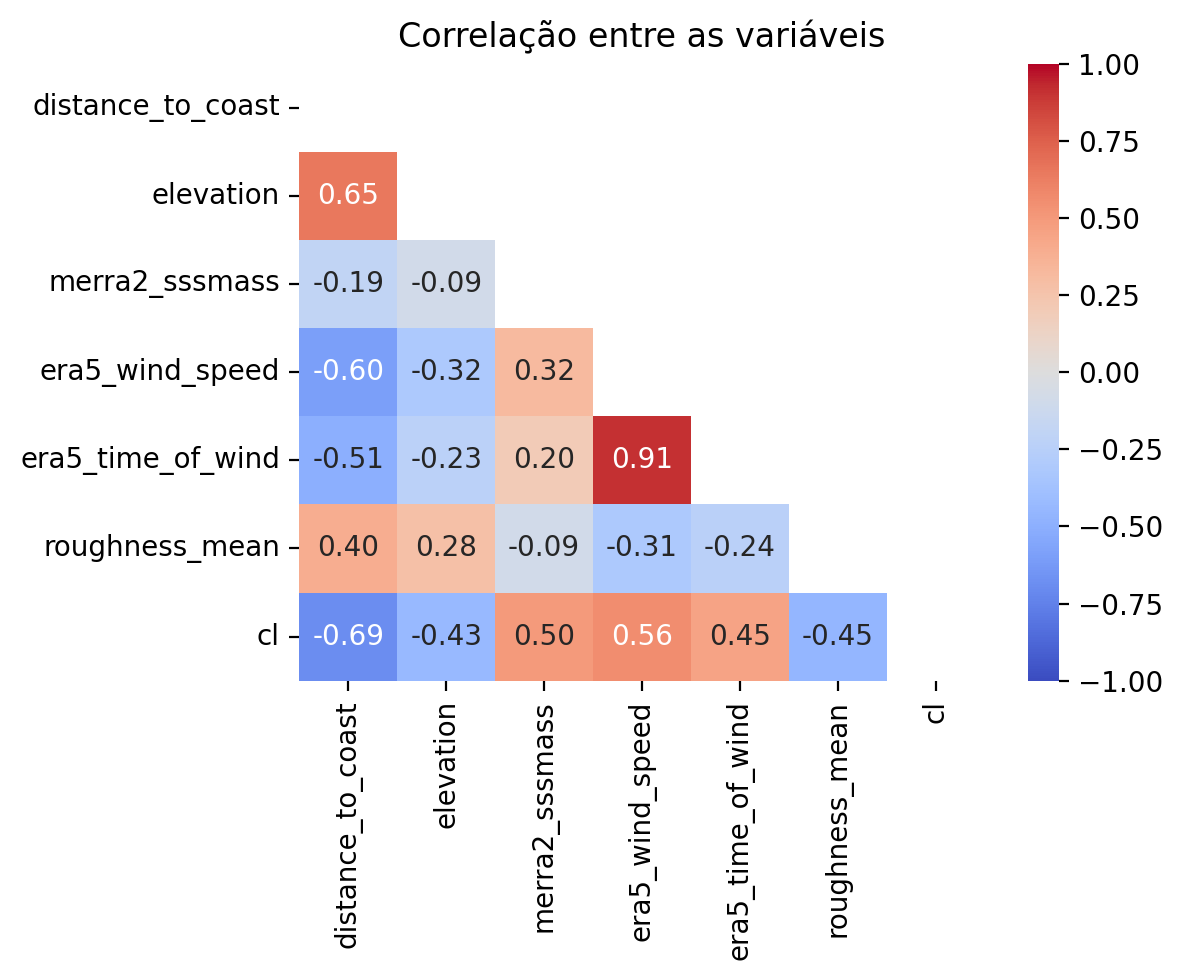

In [8]:
# Distribuição das classes de salinidade
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.countplot(
    x='salinity_class',
    data=df_train.sort_values('salinity_class'),
    order=['s0', 's1', 's2', 's3', 's4'],
    ax=axes[0]
)
axes[0].set_title('Treino')
axes[0].set_xlabel('Classe de salinidade')
axes[0].set_ylabel('Número de amostras')
axes[0].bar_label(axes[0].containers[0])

sns.countplot(
    x='salinity_class',
    data=df_test.sort_values('salinity_class'),
    order=['s0', 's1', 's2', 's3', 's4'],
    ax=axes[1]
)
axes[1].set_title('Teste')
axes[1].set_xlabel('Classe de salinidade')
axes[1].set_ylabel('')
axes[1].bar_label(axes[1].containers[0])

plt.suptitle('Distribuição das Classes de Salinidade')
plt.tight_layout()
plt.show()

# Matriz de correlação entre as variáveis de entrada e a variável alvo
corr_train = df_train[X_cols + [y_col]].corr(method='spearman')
mask = np.triu(np.ones_like(corr_train, dtype=bool))

plt.figure(figsize=(6,5), dpi=200)
sns.heatmap(corr_train,mask=mask,annot=True,fmt=".2f",cmap="coolwarm", vmin=-1,vmax=1)

plt.title("Correlação entre as variáveis")
plt.tight_layout()
plt.show()

## 4. Cross Validation e avaliação dos modelos sklearn

Usamos **Random Subsampling Estratificado** (Monte Carlo CV): 100 splits de 70%/30% mantendo a proporção das classes de salinidade. As métricas são a média dos 100 splits.

In [10]:
cv = StratifiedShuffleSplit(n_splits=100, train_size=0.7, random_state=RANDOM_STATE)

def evaluate_sklearn(model, X, y, stratify):
    """Avalia um modelo sklearn com Monte Carlo CV estratificado."""
    r2_list, mae_list, rmse_list = [], [], []

    X_df = pd.DataFrame(X)
    y_s  = pd.Series(y)
    strat_s = pd.Series(stratify.values)

    for tr_idx, val_idx in cv.split(X_df, strat_s):
        X_tr, X_val = X_df.iloc[tr_idx].values, X_df.iloc[val_idx].values
        y_tr, y_val = y_s.iloc[tr_idx].values, y_s.iloc[val_idx].values

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        r2_list.append(r2_score(y_val, y_pred))
        mae_list.append(mean_absolute_error(y_val, y_pred))
        rmse_list.append(np.sqrt(mean_squared_error(y_val, y_pred)))

    return {
        'R2':   np.mean(r2_list),
        'MAE':  np.mean(mae_list),
        'RMSE': np.mean(rmse_list)
    }

def evaluate_mlp(X, y, stratify):

    r2_list, mae_list, rmse_list = [], [], []

    X_df = pd.DataFrame(X)
    y_df = pd.DataFrame(y)
    strat_s = pd.Series(stratify.values)

    for tr_idx, val_idx in cv.split(X_df, strat_s):

        X_tr = X_df.iloc[tr_idx].values
        X_val = X_df.iloc[val_idx].values

        y_tr = y_df.iloc[tr_idx].values
        y_val = y_df.iloc[val_idx].values

        # normalização em cada split
        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()

        X_tr_sc = scaler_X.fit_transform(X_tr)
        X_val_sc = scaler_X.transform(X_val)

        y_tr_sc = scaler_y.fit_transform(y_tr)

        rede = NN.RedeNeural(perda='mse')

        rede.adicionar_camada(6,16,'relu','he')
        rede.adicionar_camada(16,8,'relu','he')
        rede.adicionar_camada(8,1,'linear','he')

        rede.treinar(
            X_tr_sc,
            y_tr_sc,
            epocas=100,
            taxa_aprendizado=0.1,
            tamanho_batch=32,
            verbose=False
        )

        y_pred_sc = rede.prever(X_val_sc)
        y_pred = scaler_y.inverse_transform(y_pred_sc).ravel()

        r2_list.append(r2_score(y_val.ravel(), y_pred))
        mae_list.append(mean_absolute_error(y_val.ravel(), y_pred))
        rmse_list.append(np.sqrt(mean_squared_error(y_val.ravel(), y_pred)))

    return {
        "R2": np.mean(r2_list),
        "MAE": np.mean(mae_list),
        "RMSE": np.mean(rmse_list)
    }

In [11]:
rf = RandomForestRegressor(
    n_estimators=400, min_samples_split=5, min_samples_leaf=2,
    max_features='sqrt', max_depth=15, bootstrap=False, random_state=RANDOM_STATE
)

svr = Pipeline([
    ('scaler', MinMaxScaler()),
    ('svr', SVR(kernel='rbf', gamma='scale', epsilon=0.2, C=100))
])

mlp_sk = Pipeline([
    ('scaler', MinMaxScaler()),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(16, 8),
        activation='relu',
        solver='adam',
        max_iter=100,
        random_state=RANDOM_STATE
    ))
])

sklearn_models = {'Random Forest': rf, 'SVR': svr, 'MLPRegressor (sklearn)': mlp_sk}

In [12]:
resultados_cv = {}
tempos_treino = {}

for nome, modelo in sklearn_models.items():

    print(f'\nAvaliando {nome}')

    t0 = time.time()

    resultados_cv[nome] = evaluate_sklearn(
        modelo,
        X_train_raw,
        y_train_raw.ravel(),
        stratify_train
    )

    tempos_treino[nome] = time.time()-t0

    print(f'R²: {resultados_cv[nome]["R2"]:.4f}')
    print(f'MAE: {resultados_cv[nome]["MAE"]:.2f}')
    print(f'RMSE: {resultados_cv[nome]["RMSE"]:.2f}')
    print(f'Tempo: {tempos_treino[nome]:.2f}s')

print("\nAvaliando Nossa MLP")

t0 = time.time()

resultados_cv["MLP (nossa biblioteca)"] = evaluate_mlp(
    X_train_raw,
    y_train_raw,
    stratify_train
)

tempos_treino["MLP (nossa biblioteca)"] = time.time()-t0

print(f'R²: {resultados_cv["MLP (nossa biblioteca)"]["R2"]:.4f}')
print(f'MAE: {resultados_cv["MLP (nossa biblioteca)"]["MAE"]:.2f}')
print(f'RMSE: {resultados_cv["MLP (nossa biblioteca)"]["RMSE"]:.2f}')
print(f'Tempo: {tempos_treino["MLP (nossa biblioteca)"]:.2f}s')


Avaliando Random Forest
R²: 0.8157
MAE: 22.33
RMSE: 46.53
Tempo: 79.75s

Avaliando SVR
R²: 0.1372
MAE: 40.21
RMSE: 102.17
Tempo: 2.09s

Avaliando MLPRegressor (sklearn)
R²: -0.1990
MAE: 50.18
RMSE: 120.34
Tempo: 13.53s

Avaliando Nossa MLP
R²: 0.2594
MAE: 53.98
RMSE: 94.05
Tempo: 18.73s


## 5. Treinamento final dos modelos com todos os dados de treino

In [14]:
# Random Forest
rf.fit(X_train_raw, y_train_raw.ravel())

# SVR
svr.fit(X_train_raw, y_train_raw.ravel())

# sklearn MLP
mlp_sk.fit(X_train_raw, y_train_raw.ravel())

# Nossa MLP
rede = NN.RedeNeural(perda='mse')

rede.adicionar_camada(6,16,'relu','he')
rede.adicionar_camada(16,8,'relu','he')
rede.adicionar_camada(8,1,'linear','he')

t0 = time.time()

rede.treinar(
    X_train_sc,
    y_train_sc,
    epocas=100,
    taxa_aprendizado=0.1,
    tamanho_batch=32,
    verbose=True
)

tempo_final_mlp = time.time()-t0

Época     1/100 | Perda treino: 0.027590
Época    10/100 | Perda treino: 0.014338
Época    20/100 | Perda treino: 0.013606
Época    30/100 | Perda treino: 0.015756
Época    40/100 | Perda treino: 0.012952
Época    50/100 | Perda treino: 0.011702
Época    60/100 | Perda treino: 0.011428
Época    70/100 | Perda treino: 0.011831
Época    80/100 | Perda treino: 0.011240
Época    90/100 | Perda treino: 0.010844
Época   100/100 | Perda treino: 0.010168


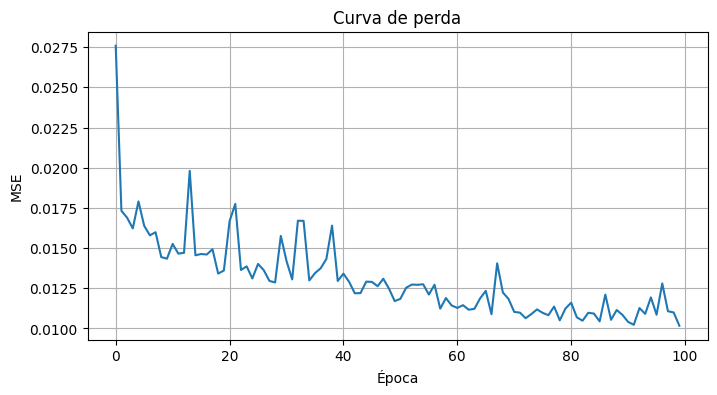

In [15]:
plt.figure(figsize=(8,4))
plt.plot(rede.historico["perda_treino"])
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Curva de perda")
plt.grid(True)
plt.show()

In [16]:
preds_train = {
    "Random Forest": rf.predict(X_train_raw),
    "SVR":svr.predict(X_train_raw),
    "MLPRegressor (sklearn)":mlp_sk.predict(X_train_raw),
    "MLP (nossa biblioteca)":scaler_y.inverse_transform(rede.prever(X_train_sc)).ravel()
}

In [17]:
resultados_treino = {}
for nome, pred in preds_train.items():
    resultados_treino[nome] = {
        "R2":r2_score( y_train_raw,pred),
        "MAE":mean_absolute_error(y_train_raw,pred),
        "RMSE":np.sqrt(mean_squared_error(y_train_raw,pred))
    }

df_treino = (pd.DataFrame(resultados_treino).T.round(4))
print("Resultados no conjunto de treino")
display(df_treino.sort_values("R2",ascending=False))

Resultados no conjunto de treino


,R2,MAE,RMSE
Random Forest,0.9675,8.2638,18.8581
MLP (nossa biblioteca),0.4556,39.9429,77.2348
SVR,0.2090,36.0024,93.1007
MLPRegressor (sklearn),-0.1292,44.6538,111.2360


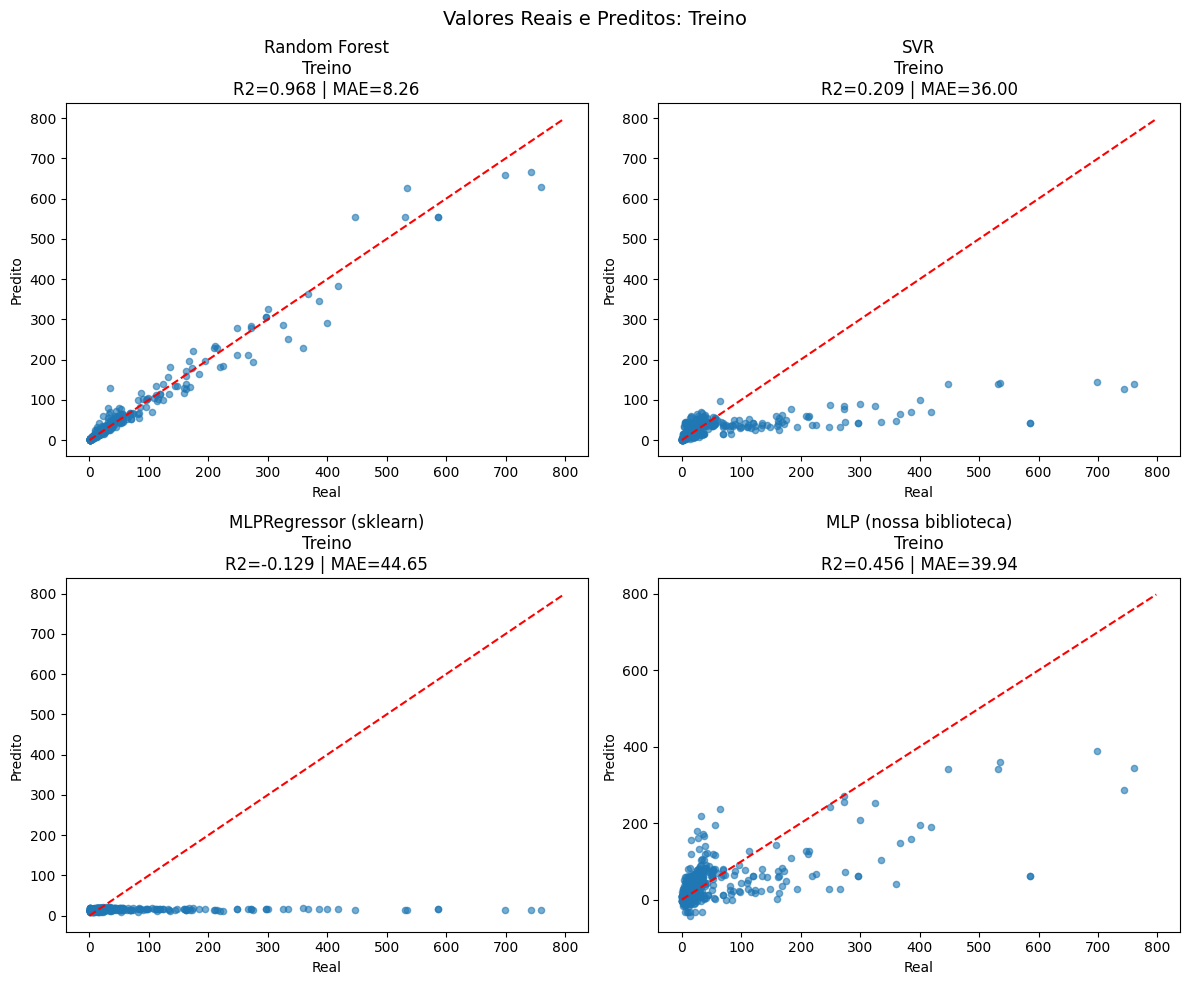

In [18]:
fig, axes = plt.subplots(2,2,figsize=(12,10))
axes = axes.ravel()

for ax, (nome, pred) in zip(axes, preds_train.items()):
    ax.scatter(y_train_raw,pred,alpha=.6,s=20)
    lim = max(y_train_raw.max(),pred.max()) * 1.05
    ax.plot([0,lim],[0,lim],'r--')
    r2 = r2_score(y_train_raw,pred)
    mae = mean_absolute_error(y_train_raw,pred)

    ax.set_title(f"{nome}\nTreino\n"f"R2={r2:.3f} | "f"MAE={mae:.2f}")
    ax.set_xlabel("Real")
    ax.set_ylabel("Predito")

plt.suptitle("Valores Reais e Preditos: Treino",fontsize=14)
plt.tight_layout()
plt.show()

## 6. Predição no conjunto de teste

In [19]:
preds_teste = {}

preds_teste["Random Forest"] = rf.predict(X_test_raw)
preds_teste["SVR"] = svr.predict(X_test_raw)
preds_teste["MLPRegressor (sklearn)"] = mlp_sk.predict(X_test_raw)

y_pred_sc = rede.prever(X_test_sc)
preds_teste["MLP (nossa biblioteca)"] = scaler_y.inverse_transform(y_pred_sc).ravel()

In [ ]:
resultados_teste = {}

for nome, pred in preds_teste.items():
    resultados_teste[nome] = {
        "R2": r2_score(y_test_raw, pred),
        "MAE": mean_absolute_error(y_test_raw, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_raw, pred))}

In [21]:
df_teste = pd.DataFrame(resultados_teste).T.round(4)
print("\nResultados no conjunto de teste")
display(df_teste.sort_values("R2", ascending=False))


Resultados no conjunto de teste


,R2,MAE,RMSE
Random Forest,0.9597,13.0458,31.0565
MLP (nossa biblioteca),-0.0160,77.9371,155.8680
SVR,-0.1086,79.9333,162.8220
MLPRegressor (sklearn),-0.2591,84.6801,173.5182


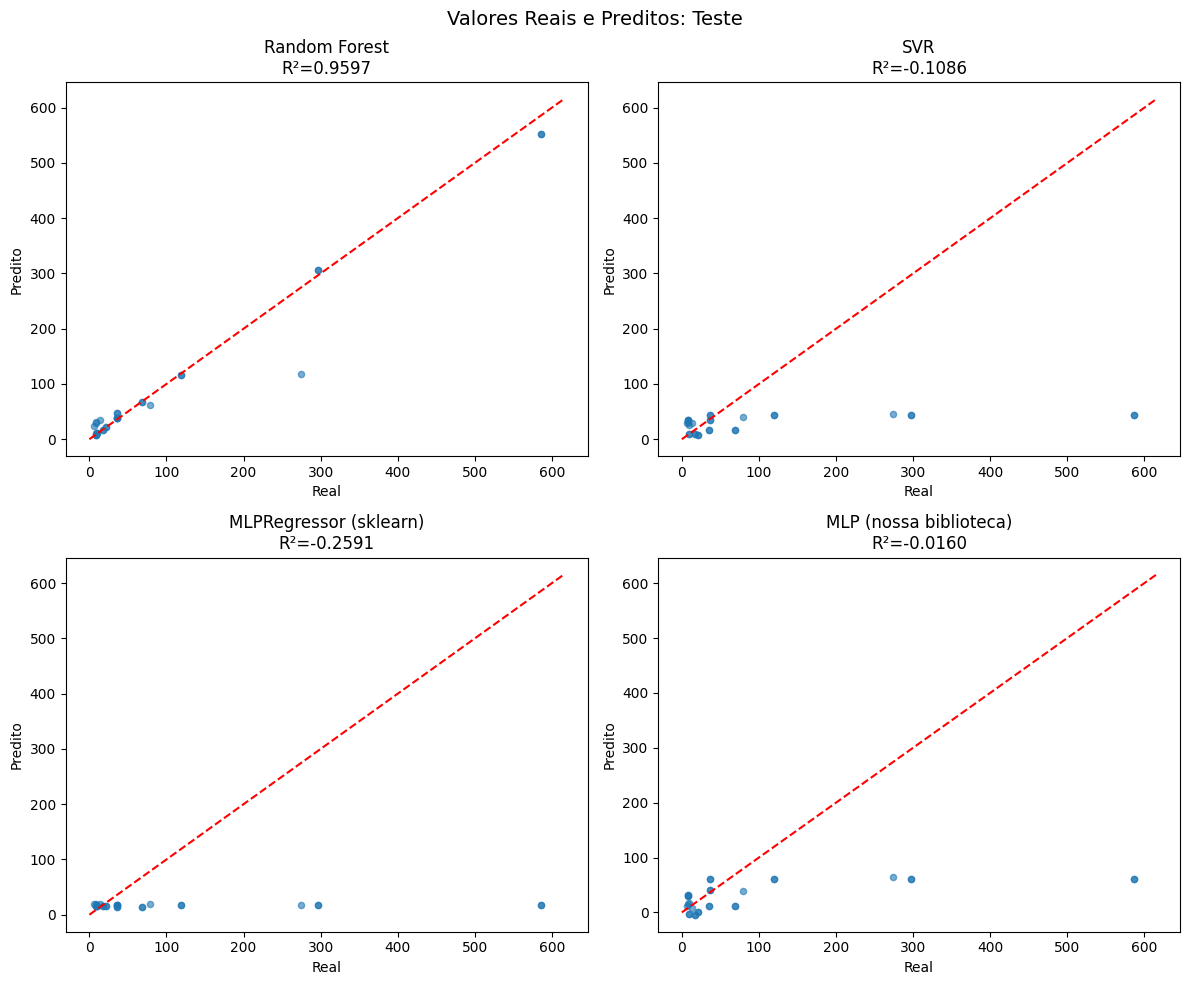

In [23]:
fig, axes = plt.subplots(2,2,figsize=(12,10))

axes = axes.ravel()

for ax, (nome, pred) in zip(axes, preds_teste.items()):
    ax.scatter(y_test_raw,pred,alpha=.6,s=20)
    lim = max(y_test_raw.max(), pred.max())*1.05
    ax.plot([0,lim],[0,lim],'r--')
    ax.set_title(f'{nome}\nR²={r2_score(y_test_raw,pred):.4f}')
    ax.set_xlabel("Real")
    ax.set_ylabel("Predito")
plt.suptitle("Valores Reais e Preditos: Teste",fontsize=14)
plt.tight_layout()
plt.show()